<a href="https://colab.research.google.com/github/PrachiShirsath/IBM_BASICS_OF_QUANTUMINFO/blob/main/IBM_Basics_of_Quantum_Information_Organized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IBM Basics of Quantum Information

## Contents
1. Single System
   - Vectors and matrices in Python
   - States, measurements, and operations
   - Simulating measurements using Statevector
   - Operations with Operator and Statevector
   - Preview of quantum circuits
2. Multiple System
   - Tensor Products
   - Operator tensor products
   - Controlled-X operation
   - Partial Measurements


# Single System


In [ ]:
!pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.8 MB/s eta 0:00:00


In [ ]:
!pip install jupyter
!pip install sympy
!pip install matplotlib
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.3/915.3 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.4 MB/s eta 0:00:00


In [ ]:
from qiskit import __version__

print(__version__)

2.5.2


**1.Vectors and matrices in python**

defines two column vectors, ket0 and ket1, corresponding to the qubit state vectors
∣0⟩ and ∣1⟩, and then prints their average.

In [ ]:
import numpy as np

ket0 = np.array([[1],[0]])
ket1 = np.array([[0],[1]])

print(ket0 / 2 + ket1 /2)

[[0.5]
 [0.5]]


Using array to create matrices that can represent operations

In [ ]:
M1 = np.array([[1,1],[0,0]])
M2 = np.array([[1,0],[0,1]])

M = M1 / 2 + M2 / 2
print(M)

[[1.  0.5]
 [0.  0.5]]


Matrix multiplication, including matrix-vector multiplication as a special case, can be performed using the @ operator

In [ ]:
print(M1 @ ket1)
print(M1 @ M2)
print(M @ M)

[[1]
 [0]]
[[1 1]
 [0 0]]
[[1.   0.75]
 [0.   0.25]]


For situations that demand something prettier, is to use thearray_to_latex function in Qiskit, from the qiskit.visualization module

In [ ]:
from qiskit.visualization import array_to_latex

display(array_to_latex(M1 @ ket1))
display(array_to_latex(M1 @ M2))
display(array_to_latex(M @ M))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

**2.States, measurements, and operations**

*2.1 Define and display state vectors*

The Statevector class in Qiskit provides functionality for defining and manipulating quantum state vectors

In [ ]:
from qiskit.quantum_info import Statevector
from numpy import sqrt

u = Statevector([1 / sqrt(2), 1 / sqrt(2)])
v = Statevector([(1 + 2.0j) / 3, -2 / 3])
w = Statevector([1 / 3, 2 / 3])


The Statevector class includes a draw method for displaying state vectors in a variety of ways, including text for plain text, latex for rendered LaTeX, and latex_source for LaTeX code, which can be handy for cutting and pasting into documents.

In [ ]:
display(u.draw("text"))
display(u.draw("latex"))
print(u.draw("Latex_source"))

[0.70710678+0.j,0.70710678+0.j]

<IPython.core.display.Latex object>

\frac{\sqrt{2}}{2} |0\rangle+\frac{\sqrt{2}}{2} |1\rangle


The Statevector class also includes is_valid method, to see if given vector is valid quantum state vector or not.

In [ ]:
display(u.is_valid())
display(w.is_valid())

True

False

*2.2 Simulating measurements using Statevector*

In [ ]:
display(v.draw("latex"))

<IPython.core.display.Latex object>

Measure method simulates a standard basis measurement and outcome of that measurement, plus the new quantum state vector of the system after the measurement.

Note: Statevector will throw an error if the measure method is applied to an invalid quantum state vector.

In [ ]:
outcome, state = v.measure()
print(f"Measured: {outcome}\nPost-measurement state:")
display(state.draw("latex"))

Measured: 0
Post-measurement state:


<IPython.core.display.Latex object>

Statevector also comes with a sample_counts method that allows for the simulation of any number of measurements on the system, each time starting with a fresh copy of the state

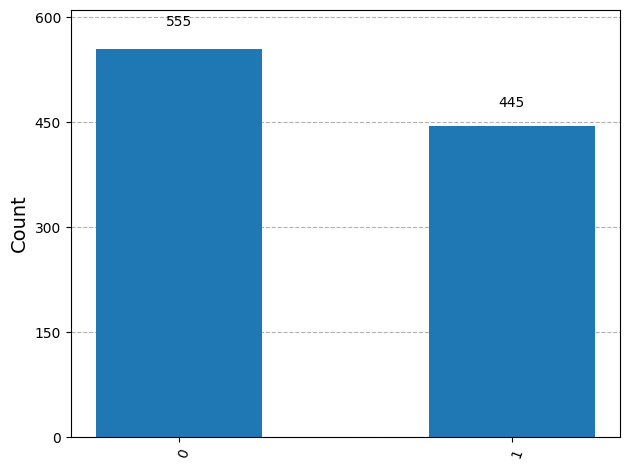

In [ ]:
from qiskit.visualization import plot_histogram

statistics = v.sample_counts(1000)
plot_histogram(statistics)


*2.3 Perform operations with Operator and Statevector*


Unitary operations can be defined in Qiskit using the Operator class

In [ ]:
from qiskit.quantum_info import Operator

Y = Operator([[0, -1.0j], [1.0j, 0]])
H = Operator([[1 / sqrt(2), 1 / sqrt(2)], [1 / sqrt(2), -1 / sqrt(2)]])
S = Operator([[1, 0], [0, 1.0j]])
T = Operator([[1, 0], [0, (1+1.0j) / sqrt(2)]])

display(T.draw("latex"))
display(S.draw("text"))
display(S.draw("latex"))


<IPython.core.display.Latex object>

[[1.+0.j,0.+0.j],
 [0.+0.j,0.+1.j]]

<IPython.core.display.Latex object>

We can apply a unitary operation to a state vector using the evolve method.

In [ ]:
v = Statevector([1, 0])

v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(H)
v = v.evolve(S)
v = v.evolve(Y)

display(v.draw("latex"))

<IPython.core.display.Latex object>

*2.4 A preview of quantum circuits*

we're using the draw method from the QuantumCircuit class with the mpl renderer (short for Matplotlib, a Python visualization library).

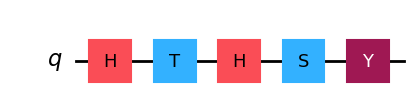

In [ ]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(1)

circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.s(0)
circuit.y(0)

display(circuit.draw(output="mpl"))


 A handy way to get the unitary matrix corresponding to this circuit is to use the "from_circuit" method from the Operator class

In [ ]:
display(Operator.from_circuit(circuit).draw("latex"))

<IPython.core.display.Latex object>

We can also initialize a starting quantum state vector and then evolve that state according to the sequence of operations described by the circuit.

In [ ]:
ket0 = Statevector([1,0])
v = ket0.evolve(circuit)
display(v.draw("latex"))

<IPython.core.display.Latex object>

The following code simulates an experiment where the state obtained from the circuit above is measured with a standard basis measurement 4000 times

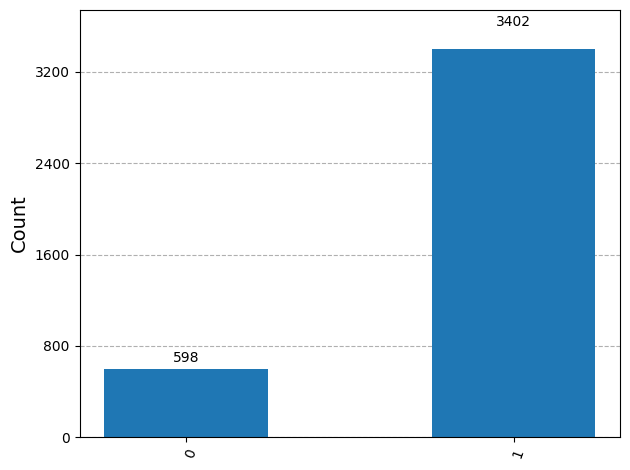

In [ ]:
statistics = v.sample_counts(4000)
display(plot_histogram(statistics))

# Multiple System


**1. Tensor Products**

The Statevector class has a tensor method, which returns the tensor product of that Statevector with another.we create two state vectors representing
∣0⟩ and ∣1⟩, and use the tensor method to create a new vector,
∣ψ⟩=∣0⟩⊗∣1⟩. Notice here that we're using the from_label method to define the states ∣0⟩ and ∣1⟩, rather than defining them ourselves.

In [ ]:
zero = Statevector.from_label("0")
one = Statevector.from_label("1")
psi = zero.tensor(one)

display(psi.draw("latex"))

<IPython.core.display.Latex object>

labels include "+" and "-" for the plus and minus states, as well as "r" and "l" (short for "right" and "left") for the states


In [ ]:
plus = Statevector.from_label("+")
minus_i = Statevector.from_label("l")
phi = plus.tensor(minus_i)
display(phi.draw("latex"))

<IPython.core.display.Latex object>

An alternative is to use the ^ operation for tensor products, which naturally gives the same results.

In [ ]:
display((plus ^ minus_i).draw("latex"))

<IPython.core.display.Latex object>

The Operator class also has a tensor method (as well as a from_label method)

In [ ]:
H = Operator.from_label("H")
Id = Operator.from_label("I")
X = Operator.from_label("X")
display(H.tensor(Id).draw("latex"))
display(H.tensor(Id).tensor(X).draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Again, like in the vector case, the ^ operation is equivalent

In [ ]:
display((H ^ Id ^ X).draw("latex"))

<IPython.core.display.Latex object>

(H⊗I)∣ϕ⟩ for ∣ϕ⟩=∣+⟩⊗∣−i⟩

In [ ]:
display(phi.evolve(H ^ Id).draw("latex"))

<IPython.core.display.Latex object>

CX operation and calculates
C
X
∣
ψ
⟩for
∣ψ⟩=∣+⟩⊗∣0⟩

In [ ]:
CX = Operator([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]])
psi = plus.tensor(zero)
display(psi.evolve(CX).draw("latex"))

<IPython.core.display.Latex object>

**2. Partial Measurements**

In [ ]:
w = Statevector([0, 1, 1, 0, 1, 0, 0, 0] / sqrt(3))
display(w.draw("latex"))

result, state = w.measure([0])
print(f"Measured: {result}\nState after measurement:")
display(state.draw("latex"))

result, state = w.measure([0, 1])
print(f"Measured: {result}\nState after measurement:")
display(state.draw("latex"))

<IPython.core.display.Latex object>

Measured: 0
State after measurement:


<IPython.core.display.Latex object>

Measured: 01
State after measurement:


<IPython.core.display.Latex object>